## Load Data as Dataframe

In [79]:
import numpy as np
import pandas as pd

In [80]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [81]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [82]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [83]:
X = df.drop("PE", axis=1)
y = df["PE"]

## Preprocess data

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [87]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

## Load data to Tensor

In [88]:
type(X_train_scaled)

numpy.ndarray

In [89]:
type(y_train)

pandas.Series

In [90]:
import torch
import torch.nn as nn

In [91]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [92]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [93]:
from torch.utils.data import TensorDataset, DataLoader


In [94]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [95]:
class ANN(nn.Module):
    def __init__(self):
        super (ANN, self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1)
        )

    def forward(self, x):
        return self.model(x)

## Loss, Optimizer

In [99]:
import torch.optim as optim

model = ANN()
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## Training The ANN

In [100]:
epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    #train model

    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        # xb => features of 1 batch
        # yb => labels of 1 batch
        optimizer.zero_grad() # reset gradient to zero
        outputs = model(xb) # forward propagation => predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # backward propagation => computes gradients
        optimizer.step() # params (weight, bias) update
        running_loss += loss.item() # loss is tensor, need to convert python float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ===> train loss: {epoch_train_loss} and val loss: {epoch_val_loss}")


epoch 1/50 ===> train loss: 205343.119921875 and val loss: 202081.41302083334
epoch 2/50 ===> train loss: 191795.17649739582 and val loss: 175847.06067708333
epoch 3/50 ===> train loss: 151244.0865234375 and val loss: 122816.03984375
epoch 4/50 ===> train loss: 95118.1526204427 and val loss: 69320.84720052083
epoch 5/50 ===> train loss: 52519.53762207031 and val loss: 38720.72275390625
epoch 6/50 ===> train loss: 30760.466072591145 and val loss: 24060.554622395834
epoch 7/50 ===> train loss: 20284.961462402345 and val loss: 16999.45926106771
epoch 8/50 ===> train loss: 14957.409857177734 and val loss: 12937.16435546875
epoch 9/50 ===> train loss: 11412.964385986328 and val loss: 9852.972517903645
epoch 10/50 ===> train loss: 8606.568231201172 and val loss: 7316.338277180989
epoch 11/50 ===> train loss: 6320.70625 and val loss: 5289.152815755208
epoch 12/50 ===> train loss: 4547.177468872071 and val loss: 3781.117226155599
epoch 13/50 ===> train loss: 3263.2121831258137 and val loss: 26

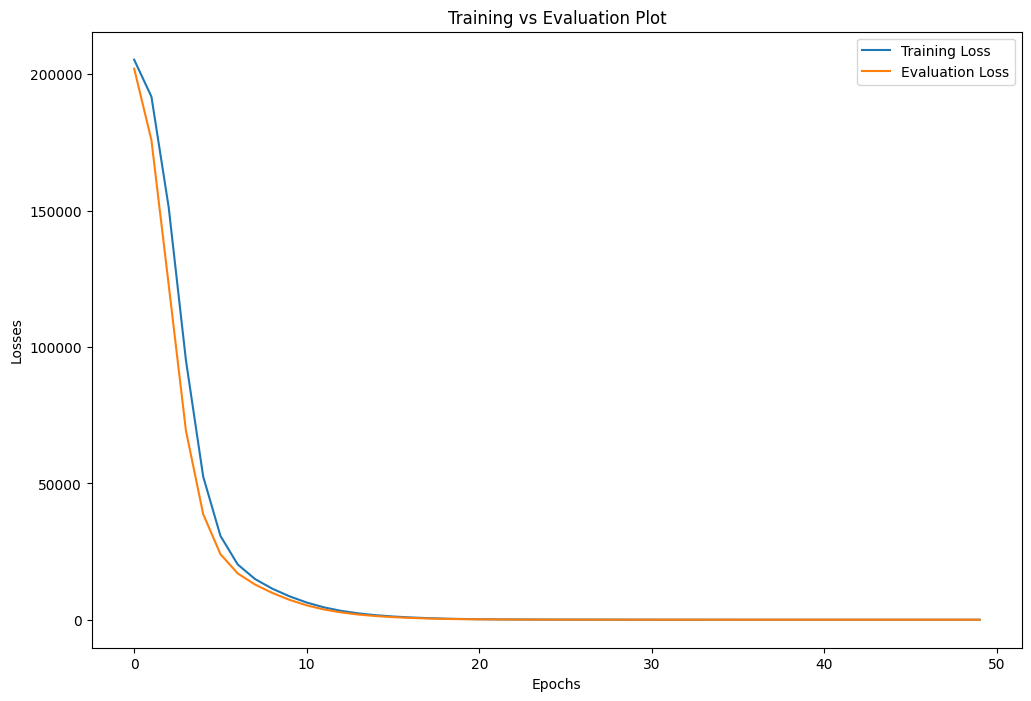

In [104]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_Loss": train_losses,
    "Evaluation_Loss": val_losses,
})

plt.figure(figsize=(12,8))

plt.plot(loss_df["Training_Loss"], label="Training Loss")
plt.plot(loss_df["Evaluation_Loss"], label="Evaluation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.title("Training vs Evaluation Plot")
plt.legend()

